In [445]:
import utils
import numpy as np
import pandas as pd
import os
from scipy.stats import chisquare

import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme
sns.set_theme()

pd.set_option('future.no_silent_downcasting', True)
#pd.set_option('display.max_rows', None)

In [446]:
# Make output folders
WSLS_output_dir = os.path.join('..','..','plots','behavioural_pilot','behavioural_modelling','WSLS')
if not os.path.exists(WSLS_output_dir):
    os.makedirs(WSLS_output_dir)
CSIS_output_dir = os.path.join('..','..','plots','behavioural_pilot','behavioural_modelling','CSIS')
if not os.path.exists(CSIS_output_dir):
    os.makedirs(CSIS_output_dir)

In [447]:
# Preparation
experiment_output_path = os.path.join('..', '..', '..', 'phd_1_task', 'experiment_output', 'behavioural_files')
#experiment_output_path = os.path.join('..', '..', '..', 'phd_1_task', 'experiment_output_verena')

In [448]:
unique_subject_ids = list(range(901, 916))
unique_sessions = [1]

recent_results = utils.analysis_functions.list_files_with_date_and_subject_id(experiment_output_path, unique_subject_ids, unique_sessions)
print(recent_results)

['../../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-901_session-01_dummy_2024-06-26_11-18-46.csv', '../../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-902_session-01_dummy_2024-06-26_13-40-01.csv', '../../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-903_session-01_dummy_2024-06-26_15-40-24.csv', '../../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-904_session-01_dummy_2024-06-27_09-44-36.csv', '../../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-905_session-01_dummy_2024-06-27_11-10-43.csv', '../../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-906_session-01_dummy_2024-06-27_13-39-31.csv', '../../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-907_session-01_dummy_2024-06-27_15-07-37.csv', '../../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-908_session-01_dummy_2024-06-2

In [449]:
# Opens all the files and combines them into one dataframe
combined_results_dataframe = utils.analysis_functions.combine_result_files(recent_results)
if 'verena' in experiment_output_path:
    combined_dataframe = combined_results_dataframe[~combined_results_dataframe['stimuli_type'].isin([2, 4])]
    
print(combined_results_dataframe)

       trial  emotional_cue_time response objectively_correct  \
0          0        1.719394e+09      NaN                Late   
1          1        1.719394e+09       up                Even   
2          2        1.719394e+09       up                Even   
3          3        1.719394e+09     down                Even   
4          4        1.719394e+09     down                Even   
...      ...                 ...      ...                 ...   
10195    675        1.720007e+09       up                True   
10196    676        1.720007e+09     down                True   
10197    677        1.720007e+09       up                True   
10198    678        1.720007e+09     down                True   
10199    679        1.720007e+09       up                True   

      subjectively_correct  response_time   RT_s  stimuli_type  iti  \
0                     Late   1.719394e+09  1.202             1    3   
1                     True   1.719394e+09  1.201             3    2   
2     

# WSLS
Determine how often the Win-Stay Lost-Shift strategy is used. Plot whether there is a difference between conditions.

In [450]:
# Add congruency as a column
combined_results_dataframe['congruency'] = combined_results_dataframe.apply(utils.analysis_functions.check_congruency, axis=1)

In [451]:
# Add two 'one-back' columns and a WSLS column
dataframe_WSLS = utils.learning_models.add_WSLS_column(combined_results_dataframe)
dataframe_CSIS = utils.learning_models.add_CSIS_column(dataframe_WSLS)

     subject_id     session  stimuli_type  trial  \
0       sub-901  session-01             1      0   
5863    sub-909  session-01             3    167   
4285    sub-907  session-01             1    411   
3102    sub-905  session-01             3     85   
349     sub-901  session-01             3     18   
...         ...         ...           ...    ...   
8754    sub-913  session-01             3    510   
2995    sub-905  session-01             1    550   
2565    sub-904  session-01             3    371   
7197    sub-911  session-01             3    113   
4527    sub-907  session-01             3    215   

     subjectively_correct_one_back response_one_back response  WSLS  
0                              NaN               NaN      NaN     0  
5863                          Late               NaN     down     0  
4285                          Late               NaN     down     0  
3102                          Late               NaN       up     0  
349                      

# Check congruency, valence and volatility
### For WSLS

In [452]:
# Check a block's congruency
dataframe_WSLS['congruency'] = dataframe_WSLS.apply(utils.analysis_functions.check_congruency, axis=1)

# Check a block's valence
dataframe_WSLS['valence'] = dataframe_WSLS.apply(utils.analysis_functions.check_valence, axis=1)

# Check a block's volatility
dataframe_WSLS = dataframe_WSLS[dataframe_WSLS['probability_condition'] != 50]
dataframe_with_volatility = dataframe_WSLS.groupby('stimuli_type', group_keys=False).apply(utils.analysis_functions.check_volatility)
dataframe_with_volatility = dataframe_with_volatility.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])
dataframe_with_volatility.reset_index(drop=True, inplace=True)
print(dataframe_with_volatility[['subject_id', 'session', 'congruency', 'valence', 'volatility', 'WSLS']])

unique_valence_conditions = dataframe_with_volatility['valence'].unique()
unique_congruency_conditions = dataframe_with_volatility['congruency'].unique()
unique_volatility_conditions = dataframe_with_volatility['volatility'].unique()

dataframe_without_volatility = dataframe_WSLS

      subject_id     session congruency valence volatility  WSLS
0        sub-901  session-01  congruent   angry     stable     0
1        sub-901  session-01  congruent   angry     stable     4
2        sub-901  session-01  congruent   angry     stable     2
3        sub-901  session-01  congruent   angry     stable     1
4        sub-901  session-01  congruent   angry     stable     1
...          ...         ...        ...     ...        ...   ...
10075    sub-915  session-01  congruent   happy   volatile     4
10076    sub-915  session-01  congruent   happy   volatile     3
10077    sub-915  session-01  congruent   happy   volatile     2
10078    sub-915  session-01  congruent   happy   volatile     2
10079    sub-915  session-01  congruent   happy   volatile     2

[10080 rows x 6 columns]


/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5253/1825596363.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dataframe_with_volatility = dataframe_WSLS.groupby('stimuli_type', group_keys=False).apply(utils.analysis_functions.check_volatility)


# Plot the WSLS separately for staying and shifting
- Valence
- Volatility
- Congruency
- Valence/Volatility
- Congruency/Volatility

In [453]:
# First combine two columns
grouping_factor = 'valence'
dataframe_valence_volatility = dataframe_with_volatility

# Average the WSLS values for the staying condition
WSLS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 1) & (dataframe_valence_volatility.WSLS != 2)].index, inplace=False)
WSLS_dataframe_win_p['WSLS'] = WSLS_dataframe_win_p['WSLS'] - 1
WSLS_win_p_averages = WSLS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then do the same for the shifting condition
WSLS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 3) & (dataframe_valence_volatility.WSLS != 4)].index, inplace=False)
WSLS_dataframe_lose_p['WSLS'] = WSLS_dataframe_lose_p['WSLS'] - 3
WSLS_lose_p_averages = WSLS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then combine the two and rename the WSLS columns
WSLS_dataframe_averages = WSLS_win_p_averages[['subject_id', 'session', grouping_factor]]
WSLS_dataframe_averages['p_win_stay'] = WSLS_win_p_averages['WSLS']
WSLS_dataframe_averages['p_lose_stay'] = WSLS_lose_p_averages['WSLS']
print(WSLS_dataframe_averages)

   subject_id     session valence  p_win_stay  p_lose_stay
0     sub-901  session-01   angry    0.670391     0.486301
1     sub-901  session-01   happy    0.648485     0.414634
2     sub-902  session-01   angry    0.503401     0.465608
3     sub-902  session-01   happy    0.523810     0.368098
4     sub-903  session-01   angry    0.478788     0.531250
5     sub-903  session-01   happy    0.506173     0.391304
6     sub-904  session-01   angry    0.715116     0.529412
7     sub-904  session-01   happy    0.791444     0.514706
8     sub-905  session-01   angry    0.732620     0.514286
9     sub-905  session-01   happy    0.769231     0.420168
10    sub-906  session-01   angry    0.867816     0.861635
11    sub-906  session-01   happy    0.881356     0.860759
12    sub-907  session-01   angry    0.804878     0.462963
13    sub-907  session-01   happy    0.846890     0.469565
14    sub-908  session-01   angry    0.885321     0.578947
15    sub-908  session-01   happy    0.907080     0.5480

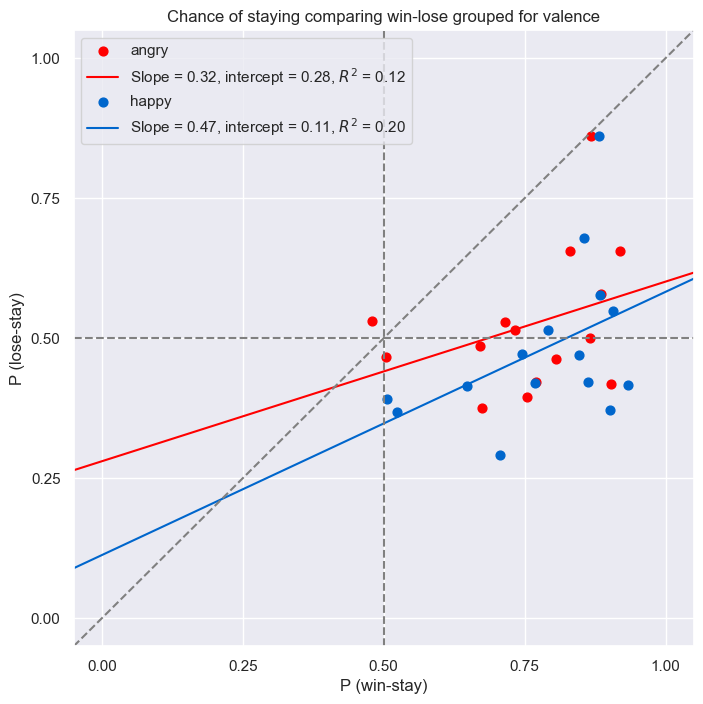

In [454]:
# Plot everything in a scatterplot
fig, ax = plt.subplots(figsize=(8, 8))
scatterplot_colours = ['#FF0000', '#0066CC']

for index, value in enumerate(unique_valence_conditions):
    filtered_dataframe = WSLS_dataframe_averages.drop(WSLS_dataframe_averages[WSLS_dataframe_averages[grouping_factor] != value].index, inplace=False)
    ax.scatter(filtered_dataframe['p_win_stay'], filtered_dataframe['p_lose_stay'], color=scatterplot_colours[index], label=value, s=40)

    # Extract x and y values
    x = filtered_dataframe['p_win_stay']
    y = filtered_dataframe['p_lose_stay']
    
    # Fit a regression line using numpy's polyfit (degree 1 for linear regression)
    slope, intercept = np.polyfit(x, y, 1)

    # Calculate the R-squared value
    correlation_matrix = np.corrcoef(x, y)
    correlation_xy = correlation_matrix[0, 1]
    r_squared = correlation_xy**2
    
    # Plot the regression line
    ax.axline((0, intercept), slope=slope, color=scatterplot_colours[index], label=f'Slope = {slope:.2f}, intercept = {intercept:.2f}, $R^2$ = {r_squared:.2f}')

# Plotting extra lines
ax.axhline(0.5, color='grey', linestyle='dashed')
ax.axvline(0.5, color='grey', linestyle='dashed')
ax.axline([0, 0], [1, 1], color='grey', linestyle='dashed')

# Adding labels and title
ax.set_xlabel('P (win-stay)')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_ylabel('P (lose-stay)')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying comparing win-lose grouped for {grouping_factor}'
ax.set_title(plot_name)
ax.legend()

plt.savefig(os.path.join(WSLS_output_dir, f'{plot_name}.pdf'))
plt.show()

In [455]:
# First combine two columns
grouping_factor = 'volatility'
dataframe_valence_volatility = dataframe_with_volatility

# Average the WSLS values for the staying condition
WSLS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 1) & (dataframe_valence_volatility.WSLS != 2)].index, inplace=False)
WSLS_dataframe_win_p['WSLS'] = WSLS_dataframe_win_p['WSLS'] - 1
WSLS_win_p_averages = WSLS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then do the same for the shifting condition
WSLS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 3) & (dataframe_valence_volatility.WSLS != 4)].index, inplace=False)
WSLS_dataframe_lose_p['WSLS'] = WSLS_dataframe_lose_p['WSLS'] - 3
WSLS_lose_p_averages = WSLS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then combine the two and rename the WSLS columns
WSLS_dataframe_averages = WSLS_win_p_averages[['subject_id', 'session', grouping_factor]]
WSLS_dataframe_averages['p_win_stay'] = WSLS_win_p_averages['WSLS']
WSLS_dataframe_averages['p_lose_stay'] = WSLS_lose_p_averages['WSLS']
print(WSLS_dataframe_averages)

   subject_id     session volatility  p_win_stay  p_lose_stay
0     sub-901  session-01     stable    0.649215     0.471264
1     sub-901  session-01   volatile    0.673203     0.419118
2     sub-902  session-01     stable    0.570552     0.455959
3     sub-902  session-01   volatile    0.453947     0.377358
4     sub-903  session-01     stable    0.448276     0.469274
5     sub-903  session-01   volatile    0.542484     0.450704
6     sub-904  session-01     stable    0.736318     0.493590
7     sub-904  session-01   volatile    0.778481     0.560345
8     sub-905  session-01     stable    0.741803     0.459259
9     sub-905  session-01   volatile    0.768212     0.483871
10    sub-906  session-01     stable    0.858586     0.842697
11    sub-906  session-01   volatile    0.895425     0.884892
12    sub-907  session-01     stable    0.837719     0.429825
13    sub-907  session-01   volatile    0.811828     0.504587
14    sub-908  session-01     stable    0.882353     0.562500
15    su

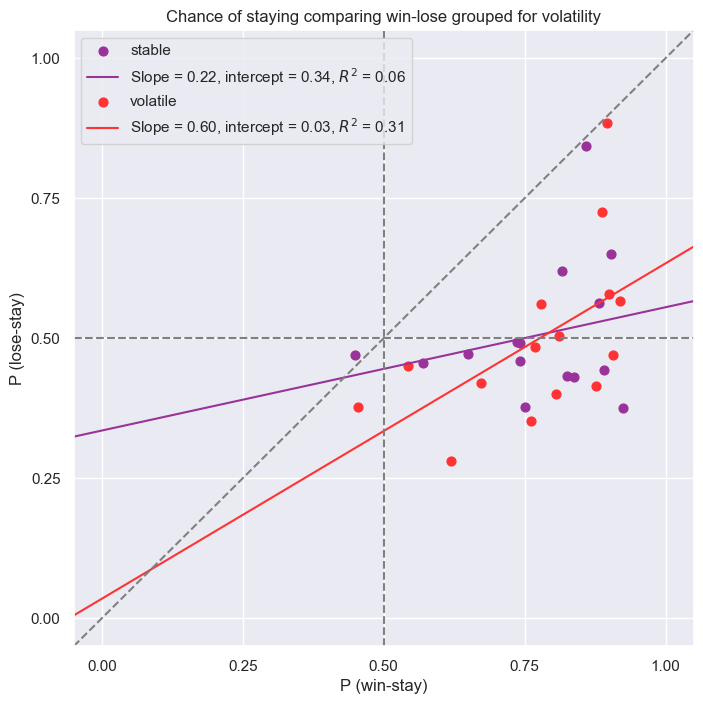

In [456]:
# Plot everything in a scatterplot
fig, ax = plt.subplots(figsize=(8, 8))
scatterplot_colours = ['#993399', '#FF3333']

for index, value in enumerate(unique_volatility_conditions):
    filtered_dataframe = WSLS_dataframe_averages.drop(WSLS_dataframe_averages[WSLS_dataframe_averages[grouping_factor] != value].index, inplace=False)
    ax.scatter(filtered_dataframe['p_win_stay'], filtered_dataframe['p_lose_stay'], color=scatterplot_colours[index], label=value, s=40)

    # Extract x and y values
    x = filtered_dataframe['p_win_stay']
    y = filtered_dataframe['p_lose_stay']

    # Fit a regression line using numpy's polyfit (degree 1 for linear regression)
    slope, intercept = np.polyfit(x, y, 1)

    # Calculate the R-squared value
    correlation_matrix = np.corrcoef(x, y)
    correlation_xy = correlation_matrix[0, 1]
    r_squared = correlation_xy**2

    # Plot the regression line
    ax.axline((0, intercept), slope=slope, color=scatterplot_colours[index], label=f'Slope = {slope:.2f}, intercept = {intercept:.2f}, $R^2$ = {r_squared:.2f}')

# Plotting extra lines
ax.axhline(0.5, color='grey', linestyle='dashed')
ax.axvline(0.5, color='grey', linestyle='dashed')
ax.axline([0, 0], [1, 1], color='grey', linestyle='dashed')

# Adding labels and title
ax.set_xlabel('P (win-stay)')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_ylabel('P (lose-stay)')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying comparing win-lose grouped for {grouping_factor}'
ax.set_title(plot_name)
ax.legend()

plt.savefig(os.path.join(WSLS_output_dir, f'{plot_name}.pdf'))
plt.show()

In [457]:
# First combine two columns
grouping_factor = 'congruency'
dataframe_valence_volatility = dataframe_with_volatility

# Average the WSLS values for the staying condition
WSLS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 1) & (dataframe_valence_volatility.WSLS != 2)].index, inplace=False)
WSLS_dataframe_win_p['WSLS'] = WSLS_dataframe_win_p['WSLS'] - 1
WSLS_win_p_averages = WSLS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then do the same for the shifting condition
WSLS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 3) & (dataframe_valence_volatility.WSLS != 4)].index, inplace=False)
WSLS_dataframe_lose_p['WSLS'] = WSLS_dataframe_lose_p['WSLS'] - 3
WSLS_lose_p_averages = WSLS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then combine the two and rename the WSLS columns
WSLS_dataframe_averages = WSLS_win_p_averages[['subject_id', 'session', grouping_factor]]
WSLS_dataframe_averages['p_win_stay'] = WSLS_win_p_averages['WSLS']
WSLS_dataframe_averages['p_lose_stay'] = WSLS_lose_p_averages['WSLS']
print(WSLS_dataframe_averages)

   subject_id     session   congruency  p_win_stay  p_lose_stay
0     sub-901  session-01    congruent    0.562130     0.450867
1     sub-901  session-01  incongruent    0.754286     0.445255
2     sub-902  session-01    congruent    0.570513     0.436242
3     sub-902  session-01  incongruent    0.459119     0.408867
4     sub-903  session-01    congruent    0.512500     0.435583
5     sub-903  session-01  incongruent    0.473054     0.487342
6     sub-904  session-01    congruent    0.757576     0.476923
7     sub-904  session-01  incongruent    0.751553     0.563380
8     sub-905  session-01    congruent    0.792208     0.460870
9     sub-905  session-01  incongruent    0.695122     0.479167
10    sub-906  session-01    congruent    0.919231     0.703297
11    sub-906  session-01  incongruent    0.747253     0.924779
12    sub-907  session-01    congruent    0.906667     0.528736
13    sub-907  session-01  incongruent    0.730159     0.426471
14    sub-908  session-01    congruent  

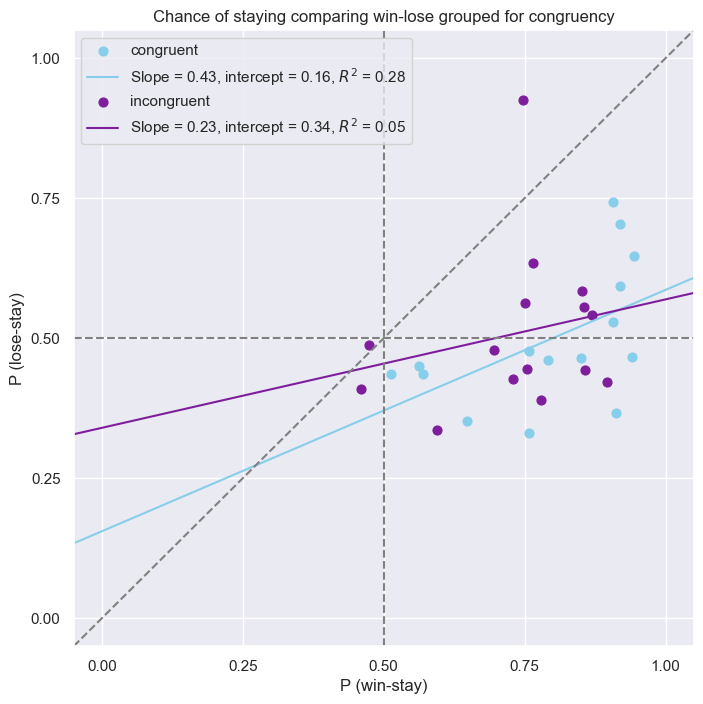

In [458]:
# Plot everything in a scatterplot
fig, ax = plt.subplots(figsize=(8, 8))
scatterplot_colours = ['#87CEEB', '#7E1E9C']

for index, value in enumerate(unique_congruency_conditions):
    filtered_dataframe = WSLS_dataframe_averages.drop(WSLS_dataframe_averages[WSLS_dataframe_averages[grouping_factor] != value].index, inplace=False)
    ax.scatter(filtered_dataframe['p_win_stay'], filtered_dataframe['p_lose_stay'], color=scatterplot_colours[index], label=value, s=40)

    # Extract x and y values
    x = filtered_dataframe['p_win_stay']
    y = filtered_dataframe['p_lose_stay']

    # Fit a regression line using numpy's polyfit (degree 1 for linear regression)
    slope, intercept = np.polyfit(x, y, 1)

    # Calculate the R-squared value
    correlation_matrix = np.corrcoef(x, y)
    correlation_xy = correlation_matrix[0, 1]
    r_squared = correlation_xy**2

    # Plot the regression line
    ax.axline((0, intercept), slope=slope, color=scatterplot_colours[index], label=f'Slope = {slope:.2f}, intercept = {intercept:.2f}, $R^2$ = {r_squared:.2f}')

# Plotting extra lines
ax.axhline(0.5, color='grey', linestyle='dashed')
ax.axvline(0.5, color='grey', linestyle='dashed')
ax.axline([0, 0], [1, 1], color='grey', linestyle='dashed')

# Adding labels and title
ax.set_xlabel('P (win-stay)')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_ylabel('P (lose-stay)')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying comparing win-lose grouped for {grouping_factor}'
ax.set_title(plot_name)
ax.legend()

plt.savefig(os.path.join(WSLS_output_dir, f'{plot_name}.pdf'))
plt.show()

In [459]:
# First combine two columns
grouping_factor_1 = 'valence'
grouping_factor_2 = 'volatility'
grouping_factor = f'{grouping_factor_1}_{grouping_factor_2}'
dataframe_valence_volatility = dataframe_with_volatility
dataframe_valence_volatility[grouping_factor] = dataframe_valence_volatility[grouping_factor_1] + ' & ' + dataframe_valence_volatility[grouping_factor_2]

# Average the WSLS values for the staying condition
WSLS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 1) & (dataframe_valence_volatility.WSLS != 2)].index, inplace=False)
WSLS_dataframe_win_p['WSLS'] = WSLS_dataframe_win_p['WSLS'] - 1
WSLS_win_p_averages = WSLS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then do the same for the shifting condition
WSLS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 3) & (dataframe_valence_volatility.WSLS != 4)].index, inplace=False)
WSLS_dataframe_lose_p['WSLS'] = WSLS_dataframe_lose_p['WSLS'] - 3
WSLS_lose_p_averages = WSLS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then combine the two and rename the WSLS columns
WSLS_dataframe_averages = WSLS_win_p_averages[['subject_id', 'session', grouping_factor]]
WSLS_dataframe_averages['p_win_stay'] = WSLS_win_p_averages['WSLS']
WSLS_dataframe_averages['p_lose_stay'] = WSLS_lose_p_averages['WSLS']
print(WSLS_dataframe_averages)

   subject_id     session valence_volatility  p_win_stay  p_lose_stay
0     sub-901  session-01     angry & stable    0.696078     0.500000
1     sub-901  session-01   angry & volatile    0.636364     0.470588
2     sub-901  session-01     happy & stable    0.595506     0.447917
3     sub-901  session-01   happy & volatile    0.710526     0.367647
4     sub-902  session-01     angry & stable    0.552632     0.490385
5     sub-902  session-01   angry & volatile    0.450704     0.435294
6     sub-902  session-01     happy & stable    0.586207     0.415730
7     sub-902  session-01   happy & volatile    0.456790     0.310811
8     sub-903  session-01     angry & stable    0.466667     0.523256
9     sub-903  session-01   angry & volatile    0.493333     0.540541
10    sub-903  session-01     happy & stable    0.428571     0.419355
11    sub-903  session-01   happy & volatile    0.589744     0.352941
12    sub-904  session-01     angry & stable    0.704082     0.493506
13    sub-904  sessi

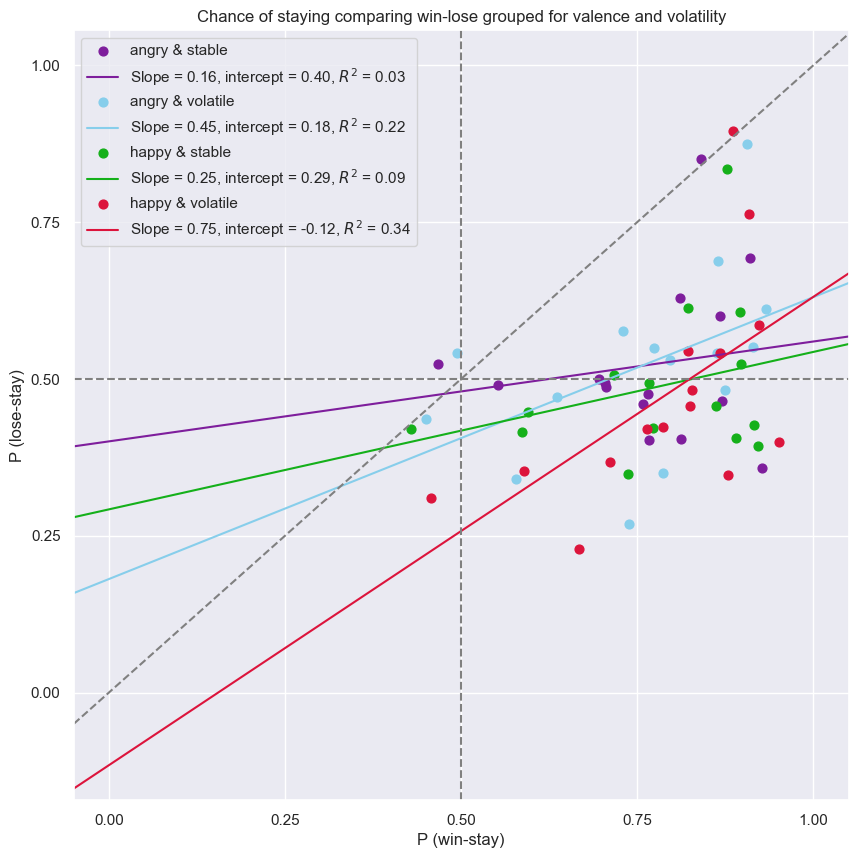

In [460]:
# Plot everything in a scatterplot
fig, ax = plt.subplots(figsize=(10, 10))
scatterplot_colours = ['#7E1E9C', '#87CEEB', '#15B01A', '#DC143C']
unique_conditions = WSLS_dataframe_averages['valence_volatility'].unique()

for index, value in enumerate(unique_conditions):
    filtered_dataframe = WSLS_dataframe_averages.drop(WSLS_dataframe_averages[WSLS_dataframe_averages[grouping_factor] != value].index, inplace=False)
    ax.scatter(filtered_dataframe['p_win_stay'], filtered_dataframe['p_lose_stay'], color=scatterplot_colours[index], label=value, s=40)

    # Extract x and y values
    x = filtered_dataframe['p_win_stay']
    y = filtered_dataframe['p_lose_stay']

    # Fit a regression line using numpy's polyfit (degree 1 for linear regression)
    slope, intercept = np.polyfit(x, y, 1)

    # Calculate the R-squared value
    correlation_matrix = np.corrcoef(x, y)
    correlation_xy = correlation_matrix[0, 1]
    r_squared = correlation_xy**2

    # Plot the regression line
    ax.axline((0, intercept), slope=slope, color=scatterplot_colours[index], label=f'Slope = {slope:.2f}, intercept = {intercept:.2f}, $R^2$ = {r_squared:.2f}')

# Plotting extra lines
ax.axhline(0.5, color='grey', linestyle='dashed')
ax.axvline(0.5, color='grey', linestyle='dashed')
ax.axline([0, 0], [1, 1], color='grey', linestyle='dashed')

# Adding labels and title
ax.set_xlabel('P (win-stay)')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_ylabel('P (lose-stay)')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying comparing win-lose grouped for {grouping_factor_1} and {grouping_factor_2}'
ax.set_title(plot_name)
ax.legend()

plt.savefig(os.path.join(WSLS_output_dir, f'{plot_name}.pdf'))
plt.show()

In [461]:
# First combine two columns
grouping_factor_1 = 'congruency'
grouping_factor_2 = 'volatility'
grouping_factor = f'{grouping_factor_1}_{grouping_factor_2}'
dataframe_valence_volatility = dataframe_with_volatility
dataframe_valence_volatility[grouping_factor] = dataframe_valence_volatility[grouping_factor_1] + ' & ' + dataframe_valence_volatility[grouping_factor_2]

# Average the WSLS values for the staying condition
WSLS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 1) & (dataframe_valence_volatility.WSLS != 2)].index, inplace=False)
WSLS_dataframe_win_p['WSLS'] = WSLS_dataframe_win_p['WSLS'] - 1
WSLS_win_p_averages = WSLS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then do the same for the shifting condition
WSLS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 3) & (dataframe_valence_volatility.WSLS != 4)].index, inplace=False)
WSLS_dataframe_lose_p['WSLS'] = WSLS_dataframe_lose_p['WSLS'] - 3
WSLS_lose_p_averages = WSLS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then combine the two and rename the WSLS columns
WSLS_dataframe_averages = WSLS_win_p_averages[['subject_id', 'session', grouping_factor]]
WSLS_dataframe_averages['p_win_stay'] = WSLS_win_p_averages['WSLS']
WSLS_dataframe_averages['p_lose_stay'] = WSLS_lose_p_averages['WSLS']
print(WSLS_dataframe_averages)

   subject_id     session   congruency_volatility  p_win_stay  p_lose_stay
0     sub-901  session-01      congruent & stable    0.563218     0.485714
1     sub-901  session-01    congruent & volatile    0.560976     0.397059
2     sub-901  session-01    incongruent & stable    0.721154     0.449275
3     sub-901  session-01  incongruent & volatile    0.802817     0.441176
4     sub-902  session-01      congruent & stable    0.682927     0.523810
5     sub-902  session-01    congruent & volatile    0.445946     0.323077
6     sub-902  session-01    incongruent & stable    0.456790     0.403670
7     sub-902  session-01  incongruent & volatile    0.461538     0.414894
8     sub-903  session-01      congruent & stable    0.434211     0.441860
9     sub-903  session-01    congruent & volatile    0.583333     0.428571
10    sub-903  session-01    incongruent & stable    0.459184     0.494624
11    sub-903  session-01  incongruent & volatile    0.492754     0.476923
12    sub-904  session-01

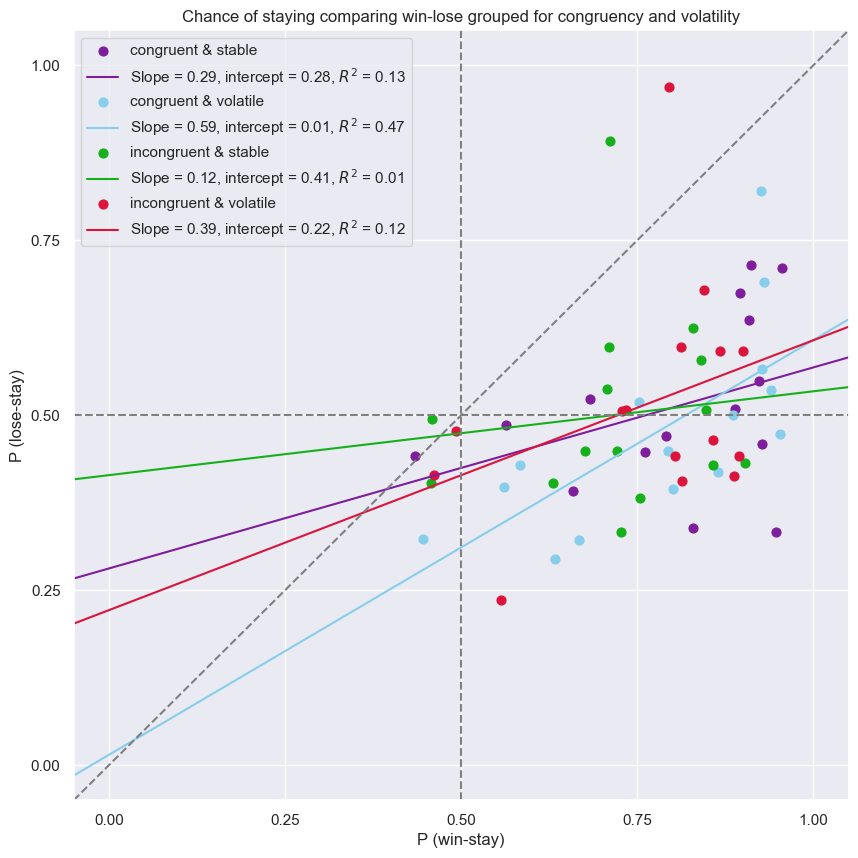

In [462]:
# Plot everything in a scatterplot
fig, ax = plt.subplots(figsize=(10, 10))
scatterplot_colours = ['#7E1E9C', '#87CEEB', '#15B01A', '#DC143C']
unique_conditions = WSLS_dataframe_averages['congruency_volatility'].unique()

for index, value in enumerate(unique_conditions):
    filtered_dataframe = WSLS_dataframe_averages.drop(WSLS_dataframe_averages[WSLS_dataframe_averages[grouping_factor] != value].index, inplace=False)
    ax.scatter(filtered_dataframe['p_win_stay'], filtered_dataframe['p_lose_stay'], color=scatterplot_colours[index], label=value, s=40)

    # Extract x and y values
    x = filtered_dataframe['p_win_stay']
    y = filtered_dataframe['p_lose_stay']

    # Fit a regression line using numpy's polyfit (degree 1 for linear regression)
    slope, intercept = np.polyfit(x, y, 1)

    # Calculate the R-squared value
    correlation_matrix = np.corrcoef(x, y)
    correlation_xy = correlation_matrix[0, 1]
    r_squared = correlation_xy**2

    # Plot the regression line
    ax.axline((0, intercept), slope=slope, color=scatterplot_colours[index], label=f'Slope = {slope:.2f}, intercept = {intercept:.2f}, $R^2$ = {r_squared:.2f}')

# Plotting extra lines
ax.axhline(0.5, color='grey', linestyle='dashed')
ax.axvline(0.5, color='grey', linestyle='dashed')
ax.axline([0, 0], [1, 1], color='grey', linestyle='dashed')

# Adding labels and title
ax.set_xlabel('P (win-stay)')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_ylabel('P (lose-stay)')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying comparing win-lose grouped for {grouping_factor_1} and {grouping_factor_2}'
ax.set_title(plot_name)
ax.legend()

plt.savefig(os.path.join(WSLS_output_dir, f'{plot_name}.pdf'))
plt.show()

# Check congruency, valence and volatility
### For CSIS (congruent-stay/incongruent-switch)

In [463]:
# Check a block's congruency
dataframe_CSIS['congruency'] = dataframe_CSIS.apply(utils.analysis_functions.check_congruency, axis=1)

# Check a block's valence
dataframe_CSIS['valence'] = dataframe_CSIS.apply(utils.analysis_functions.check_valence, axis=1)

# Check a block's volatility
dataframe_CSIS = dataframe_CSIS[dataframe_CSIS['probability_condition'] != 50]
dataframe_with_volatility = dataframe_CSIS.groupby('stimuli_type', group_keys=False).apply(utils.analysis_functions.check_volatility)
dataframe_with_volatility = dataframe_with_volatility.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])
dataframe_with_volatility.reset_index(drop=True, inplace=True)
print(dataframe_with_volatility[['subject_id', 'session', 'congruency', 'valence', 'volatility', 'CSIS']])

unique_valence_conditions = dataframe_with_volatility['valence'].unique()
unique_congruency_conditions = dataframe_with_volatility['congruency'].unique()
unique_volatility_conditions = dataframe_with_volatility['volatility'].unique()

dataframe_without_volatility = dataframe_CSIS

      subject_id     session congruency valence volatility  CSIS
0        sub-901  session-01  congruent   angry     stable     2
1        sub-901  session-01  congruent   angry     stable     1
2        sub-901  session-01  congruent   angry     stable     1
3        sub-901  session-01  congruent   angry     stable     2
4        sub-901  session-01  congruent   angry     stable     2
...          ...         ...        ...     ...        ...   ...
10075    sub-915  session-01  congruent   happy   volatile     1
10076    sub-915  session-01  congruent   happy   volatile     2
10077    sub-915  session-01  congruent   happy   volatile     1
10078    sub-915  session-01  congruent   happy   volatile     1
10079    sub-915  session-01  congruent   happy   volatile     1

[10080 rows x 6 columns]


/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5253/1031595679.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dataframe_with_volatility = dataframe_CSIS.groupby('stimuli_type', group_keys=False).apply(utils.analysis_functions.check_volatility)


# Plot the CSIS separately for staying and shifting
- Volatility
- Valence
- Valence/Volatility

In [464]:
# First combine two columns
grouping_factor = 'volatility'
dataframe_valence_volatility = dataframe_with_volatility

# Average the CSIS values for the staying condition
CSIS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.CSIS != 1) & (dataframe_valence_volatility.CSIS != 2)].index, inplace=False)
CSIS_dataframe_win_p['CSIS'] = CSIS_dataframe_win_p['CSIS'] - 1
CSIS_win_p_averages = CSIS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['CSIS'].mean().reset_index()

# Then do the same for the shifting condition
CSIS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.CSIS != 3) & (dataframe_valence_volatility.CSIS != 4)].index, inplace=False)
CSIS_dataframe_lose_p['CSIS'] = CSIS_dataframe_lose_p['CSIS'] - 3
CSIS_lose_p_averages = CSIS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['CSIS'].mean().reset_index()

# Then combine the two and rename the CSIS columns
CSIS_dataframe_averages = CSIS_win_p_averages[['subject_id', 'session', grouping_factor]]
CSIS_dataframe_averages['p_congruent_stay'] = CSIS_win_p_averages['CSIS']
CSIS_dataframe_averages['p_incongruent_stay'] = CSIS_lose_p_averages['CSIS']
print(CSIS_dataframe_averages)

   subject_id     session volatility  p_congruent_stay  p_incongruent_stay
0     sub-901  session-01     stable          0.509804            0.397727
1     sub-901  session-01   volatile          0.519737            0.378571
2     sub-902  session-01     stable          0.404762            0.578125
3     sub-902  session-01   volatile          0.614286            0.563953
4     sub-903  session-01     stable          0.587209            0.526042
5     sub-903  session-01   volatile          0.500000            0.548611
6     sub-904  session-01     stable          0.415000            0.413043
7     sub-904  session-01   volatile          0.375000            0.316176
8     sub-905  session-01     stable          0.322115            0.420455
9     sub-905  session-01   volatile          0.358108            0.421429
10    sub-906  session-01     stable          0.142857            0.173913
11    sub-906  session-01   volatile          0.134615            0.080882
12    sub-907  session-01

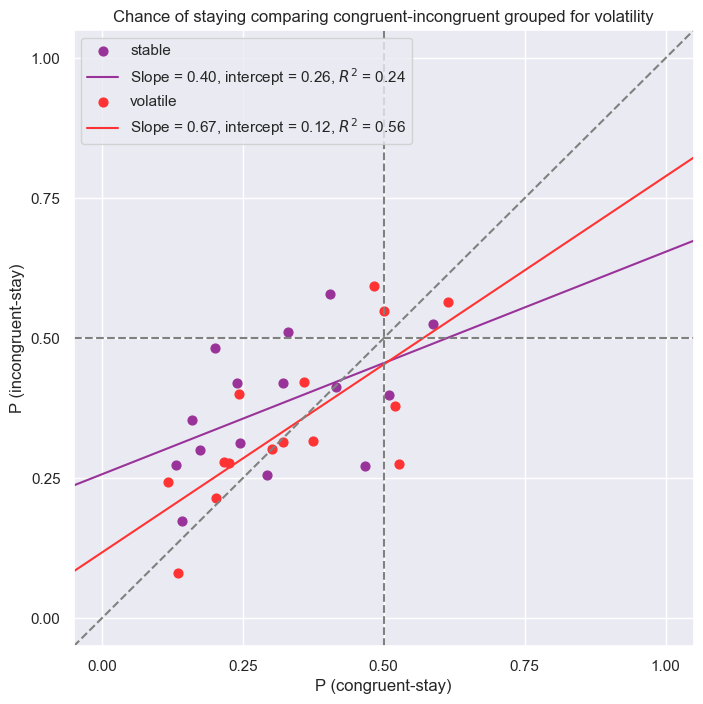

In [465]:
# Plot everything in a scatterplot
fig, ax = plt.subplots(figsize=(8, 8))
scatterplot_colours = ['#993399', '#FF3333']

for index, value in enumerate(unique_volatility_conditions):
    filtered_dataframe = CSIS_dataframe_averages.drop(CSIS_dataframe_averages[CSIS_dataframe_averages[grouping_factor] != value].index, inplace=False)
    ax.scatter(filtered_dataframe['p_congruent_stay'], filtered_dataframe['p_incongruent_stay'], color=scatterplot_colours[index], label=value, s=40)

    # Extract x and y values
    x = filtered_dataframe['p_congruent_stay']
    y = filtered_dataframe['p_incongruent_stay']

    # Fit a regression line using numpy's polyfit (degree 1 for linear regression)
    slope, intercept = np.polyfit(x, y, 1)

    # Calculate the R-squared value
    correlation_matrix = np.corrcoef(x, y)
    correlation_xy = correlation_matrix[0, 1]
    r_squared = correlation_xy**2

    # Plot the regression line
    ax.axline((0, intercept), slope=slope, color=scatterplot_colours[index], label=f'Slope = {slope:.2f}, intercept = {intercept:.2f}, $R^2$ = {r_squared:.2f}')

# Plotting extra lines
ax.axhline(0.5, color='grey', linestyle='dashed')
ax.axvline(0.5, color='grey', linestyle='dashed')
ax.axline([0, 0], [1, 1], color='grey', linestyle='dashed')

# Adding labels and title
ax.set_xlabel('P (congruent-stay)')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_ylabel('P (incongruent-stay)')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying comparing congruent-incongruent grouped for {grouping_factor}'
ax.set_title(plot_name)
ax.legend()

plt.savefig(os.path.join(CSIS_output_dir, f'{plot_name}.pdf'))
plt.show()

In [466]:
# First combine two columns
grouping_factor = 'valence'
dataframe_valence_volatility = dataframe_with_volatility

# Average the CSIS values for the staying condition
CSIS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.CSIS != 1) & (dataframe_valence_volatility.CSIS != 2)].index, inplace=False)
CSIS_dataframe_win_p['CSIS'] = CSIS_dataframe_win_p['CSIS'] - 1
CSIS_win_p_averages = CSIS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['CSIS'].mean().reset_index()

# Then do the same for the shifting condition
CSIS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.CSIS != 3) & (dataframe_valence_volatility.CSIS != 4)].index, inplace=False)
CSIS_dataframe_lose_p['CSIS'] = CSIS_dataframe_lose_p['CSIS'] - 3
CSIS_lose_p_averages = CSIS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['CSIS'].mean().reset_index()

# Then combine the two and rename the CSIS columns
CSIS_dataframe_averages = CSIS_win_p_averages[['subject_id', 'session', grouping_factor]]
CSIS_dataframe_averages['p_congruent_stay'] = CSIS_win_p_averages['CSIS']
CSIS_dataframe_averages['p_incongruent_stay'] = CSIS_lose_p_averages['CSIS']
print(CSIS_dataframe_averages)

   subject_id     session valence  p_congruent_stay  p_incongruent_stay
0     sub-901  session-01   angry          0.516854            0.335443
1     sub-901  session-01   happy          0.511236            0.443038
2     sub-902  session-01   angry          0.487013            0.543956
3     sub-902  session-01   happy          0.512987            0.598901
4     sub-903  session-01   angry          0.488095            0.535714
5     sub-903  session-01   happy          0.601190            0.535714
6     sub-904  session-01   angry          0.443182            0.393750
7     sub-904  session-01   happy          0.352273            0.350000
8     sub-905  session-01   angry          0.275281            0.493671
9     sub-905  session-01   happy          0.398876            0.348101
10    sub-906  session-01   angry          0.159091            0.125000
11    sub-906  session-01   happy          0.119318            0.143750
12    sub-907  session-01   angry          0.275000            0

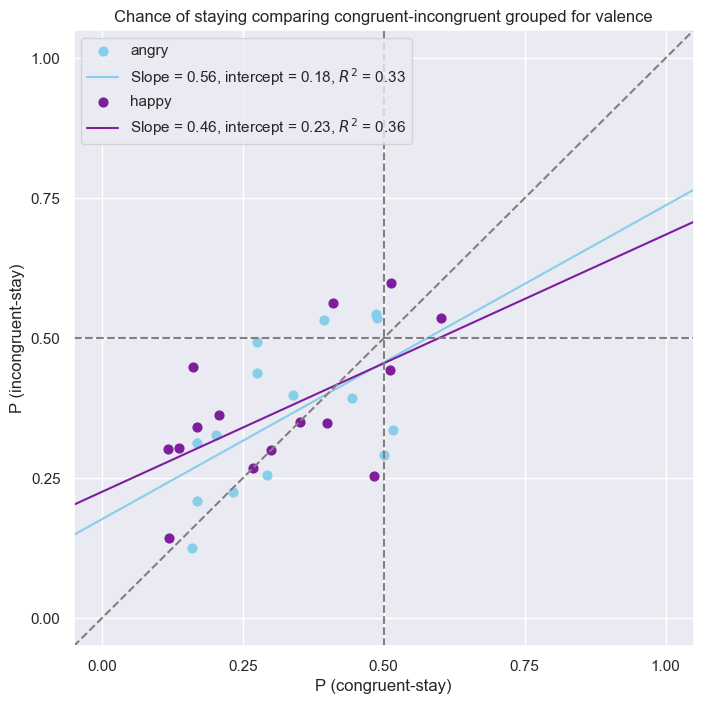

In [467]:
# Plot everything in a scatterplot
fig, ax = plt.subplots(figsize=(8 ,8))
scatterplot_colours = ['#87CEEB', '#7E1E9C']

for index, value in enumerate(unique_valence_conditions):
    filtered_dataframe = CSIS_dataframe_averages.drop(CSIS_dataframe_averages[CSIS_dataframe_averages[grouping_factor] != value].index, inplace=False)
    ax.scatter(filtered_dataframe['p_congruent_stay'], filtered_dataframe['p_incongruent_stay'], color=scatterplot_colours[index], label=value, s=40)

    # Extract x and y values
    x = filtered_dataframe['p_congruent_stay']
    y = filtered_dataframe['p_incongruent_stay']

    # Fit a regression line using numpy's polyfit (degree 1 for linear regression)
    slope, intercept = np.polyfit(x, y, 1)

    # Calculate the R-squared value
    correlation_matrix = np.corrcoef(x, y)
    correlation_xy = correlation_matrix[0, 1]
    r_squared = correlation_xy**2

    # Plot the regression line
    ax.axline((0, intercept), slope=slope, color=scatterplot_colours[index], label=f'Slope = {slope:.2f}, intercept = {intercept:.2f}, $R^2$ = {r_squared:.2f}')

# Plotting extra lines
ax.axhline(0.5, color='grey', linestyle='dashed')
ax.axvline(0.5, color='grey', linestyle='dashed')
ax.axline([0, 0], [1, 1], color='grey', linestyle='dashed')

# Adding labels and title
ax.set_xlabel('P (congruent-stay)')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_ylabel('P (incongruent-stay)')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying comparing congruent-incongruent grouped for {grouping_factor}'
ax.set_title(plot_name)
ax.legend()

plt.savefig(os.path.join(CSIS_output_dir, f'{plot_name}.pdf'))
plt.show()

In [468]:
# First combine two columns
grouping_factor_1 = 'valence'
grouping_factor_2 = 'volatility'
grouping_factor = f'{grouping_factor_1}_{grouping_factor_2}'
dataframe_valence_volatility = dataframe_with_volatility
dataframe_valence_volatility[grouping_factor] = dataframe_valence_volatility[grouping_factor_1] + ' & ' + dataframe_valence_volatility[grouping_factor_2]

# Average the CSIS values for the staying condition
CSIS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.CSIS != 1) & (dataframe_valence_volatility.CSIS != 2)].index, inplace=False)
CSIS_dataframe_win_p['CSIS'] = CSIS_dataframe_win_p['CSIS'] - 1
CSIS_win_p_averages = CSIS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['CSIS'].mean().reset_index()

# Then do the same for the shifting condition
CSIS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.CSIS != 3) & (dataframe_valence_volatility.CSIS != 4)].index, inplace=False)
CSIS_dataframe_lose_p['CSIS'] = CSIS_dataframe_lose_p['CSIS'] - 3
CSIS_lose_p_averages = CSIS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['CSIS'].mean().reset_index()

# Then combine the two and rename the CSIS columns
CSIS_dataframe_averages = CSIS_win_p_averages[['subject_id', 'session', grouping_factor]]
CSIS_dataframe_averages['p_congruent_stay'] = CSIS_win_p_averages['CSIS']
CSIS_dataframe_averages['p_incongruent_stay'] = CSIS_lose_p_averages['CSIS']
print(CSIS_dataframe_averages)

   subject_id     session valence_volatility  p_congruent_stay  \
0     sub-901  session-01     angry & stable          0.500000   
1     sub-901  session-01   angry & volatile          0.539474   
2     sub-901  session-01     happy & stable          0.519608   
3     sub-901  session-01   happy & volatile          0.500000   
4     sub-902  session-01     angry & stable          0.380952   
5     sub-902  session-01   angry & volatile          0.614286   
6     sub-902  session-01     happy & stable          0.428571   
7     sub-902  session-01   happy & volatile          0.614286   
8     sub-903  session-01     angry & stable          0.534884   
9     sub-903  session-01   angry & volatile          0.439024   
10    sub-903  session-01     happy & stable          0.639535   
11    sub-903  session-01   happy & volatile          0.560976   
12    sub-904  session-01     angry & stable          0.450000   
13    sub-904  session-01   angry & volatile          0.434211   
14    sub-

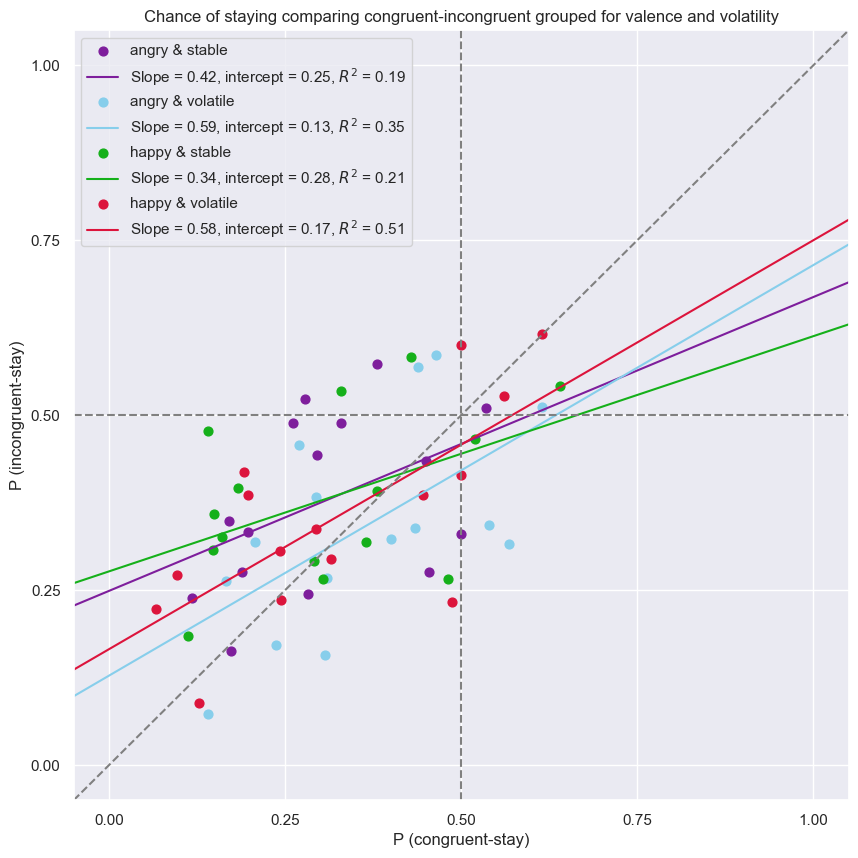

In [469]:
# Plot everything in a scatterplot
fig, ax = plt.subplots(figsize=(10, 10))
scatterplot_colours = ['#7E1E9C', '#87CEEB', '#15B01A', '#DC143C']
unique_conditions = CSIS_dataframe_averages['valence_volatility'].unique()

for index, value in enumerate(unique_conditions):
    filtered_dataframe = CSIS_dataframe_averages.drop(CSIS_dataframe_averages[CSIS_dataframe_averages[grouping_factor] != value].index, inplace=False)
    ax.scatter(filtered_dataframe['p_congruent_stay'], filtered_dataframe['p_incongruent_stay'], color=scatterplot_colours[index], label=value, s=40)

    # Extract x and y values
    x = filtered_dataframe['p_congruent_stay']
    y = filtered_dataframe['p_incongruent_stay']

    # Fit a regression line using numpy's polyfit (degree 1 for linear regression)
    slope, intercept = np.polyfit(x, y, 1)

    # Calculate the R-squared value
    correlation_matrix = np.corrcoef(x, y)
    correlation_xy = correlation_matrix[0, 1]
    r_squared = correlation_xy**2

    # Plot the regression line
    ax.axline((0, intercept), slope=slope, color=scatterplot_colours[index], label=f'Slope = {slope:.2f}, intercept = {intercept:.2f}, $R^2$ = {r_squared:.2f}')

# Plotting extra lines
ax.axhline(0.5, color='grey', linestyle='dashed')
ax.axvline(0.5, color='grey', linestyle='dashed')
ax.axline([0, 0], [1, 1], color='grey', linestyle='dashed')

# Adding labels and title
ax.set_xlabel('P (congruent-stay)')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_ylabel('P (incongruent-stay)')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying comparing congruent-incongruent grouped for {grouping_factor_1} and {grouping_factor_2}'
ax.set_title(plot_name)
ax.legend()

plt.savefig(os.path.join(CSIS_output_dir, f'{plot_name}.pdf'))
plt.show()